##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]


---

## 0. Iteration setup

**Import libraries**

In [4]:
%pip install matplotlib
%pip install scikit-learn
%pip install jinja2
import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Load dataset(s)**

In [5]:
df = pd.read_csv('herkansing/ships_inventory_iter1.csv')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

### Situation description

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.

Nebula Brokerage heeft een probleem met de prijsstelling omdat ze de prijzen baseren op een subjectief oordeel, oftewel “gut feeling”, in plaats van op data en analyses. Dit betekent dat de prijzen niet altijd aansluiten bij de markt of bij wat financieel optimaal is.

Het gebruik van deze aanpak brengt meerdere risico’s met zich mee:

1. Omzetverlies: Te lage prijzen zorgen voor gemiste winst, terwijl te hoge prijzen klanten kunnen afschrikken.

2. Concurrentienadeel: Concurrenten die data gebruiken voor hun prijsstrategie kunnen sneller inspelen op marktveranderingen en marktaandeel winnen.

3. Inconsistente prijzen: Zonder een vaste methode kunnen prijzen onvoorspelbaar veranderen, wat klanten verwart en het vertrouwen schaadt.

4. Slechte besluitvorming: Beslissingen op basis van gevoel zijn gevoelig voor vooroordelen, fouten en verkeerde inschattingen van vraag, markttrends of kosten.

Kortom, het vertrouwen op een gut feeling brengt financiële, strategische en reputatierisico’s met zich mee die met een gestructureerde, data-gedreven prijsstrategie voorkomen kunnen worden. Daarom starten we in iteratie 1 met een objectieve, data-gedreven benchmark als minimale kwaliteitsstandaard voor prijsinschattingen.  

### Business objective(s)

*Justify why a data-driven baseline is needed*

Het doel van iteratie 1 is om een betrouwbare data-gedreven baseline op te zetten voor het voorspellen van scheepsprijzen. We beoordelen deze baseline met MAE, MSE en RMSE op een vaste train-test split, zodat resultaten transparant en herhaalbaar zijn. De uitkomst van deze iteratie is een baseline die als referentie dient voor alle volgende, complexere modellen.

Een data-driven baseline is nodig omdat Nebula Brokerage nu vooral op gevoel prijst, wat leidt tot inconsistente en moeilijk te verantwoorden beslissingen. Met een baseline (bijv. het gemiddelde of de mediaan) is er een objectief startpunt waarmee je:

• Prestaties kunt meten: je ziet direct of een nieuw (complexer) model daadwerkelijk beter voorspelt dan “simpelweg het gemiddelde”. 

• Risico’s verlaagt: minder kans op structureel te hoog/te laag prijzen (omzetverlies of klantenverlies).

• Besluiten kunt onderbouwen: prijzen worden uitlegbaar naar stakeholders omdat ze gebaseerd zijn op data i.p.v. intuïtie.  

• Consistentie creëert: dezelfde invoer leidt tot dezelfde basisinschatting; dat verhoogt betrouwbaarheid en vertrouwen.  

• Sneller kunt verbeteren: de baseline fungeert als benchmark; elke iteratie kan aantoonbaar een stap vooruit zijn (bv. lagere MAE/RMSE).  

Kortom, een data-driven baseline maakt het mogelijk om prijsinschattingen meetbaar, reproduceerbaar en verbeterbaar te maken, en vormt daarmee de minimale ondergrens waaraan elk toekomstig voorspelmodel moet voldoen. 

### Data mining goal(s)

*Explain what type of modeling task this is and why.*

Het data-miningdoel in iteratie 1 is een regressietaak, omdat we een continue numerieke target voorspellen: `Galactic_Credits`. Het model leert de relatie tussen beschikbare scheepskenmerken in de dataset (zoals `Ship_Manufacturer`, `Sector` en `Model_Cycle`) en de uiteindelijke prijs. Daarmee kunnen we voor nieuwe schepen een objectieve en reproduceerbare prijsinschatting maken, als alternatief voor handmatige inschatting op basis van gut feeling. 

### Success criteria

*Determine success criteria for this iteration (the benchmark)*

Deze iteratie is succesvol wanneer we een duidelijke, reproduceerbare benchmark neerzetten voor prijsvoorspelling van Galactic_Credits.

De data wordt reproduceerbaar gesplitst in train en test.
1. Twee baseline modellen (mean en median) worden allebei geëvalueerd op dezelfde testset.
2. De prestaties worden minimaal gerapporteerd met MAE, MSE en RMSE.
3. De beste baseline wordt expliciet gekozen op basis van de laagste MAE (met RMSE als extra controle op grote fouten door uitschieters).
4. De uitkomst wordt vastgelegd als benchmark voor volgende iteraties: een nieuw model is pas beter als het een lagere MAE en lagere RMSE behaalt dan deze beste baseline.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

In dit hoofdstuk analyseren we de structuur, verdeling en kwaliteit van de dataset.
Doel: begrijpen welke patronen en datakwaliteitsproblemen invloed hebben op prijsvoorspellingen. Nu we in hoofdstuk 1 helder hebben wat het bedrijfsdoel is (een objectieve baseline maken voor de prijzen), kunnen we in deze iteratie gericht gaan kijken of de data ons dat ook daadwerkelijk toelaat.

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 14.1 MB


df.info() toont dat de dataset 5 kolommen bevat met een mix van numerieke (Ship_ID, Model_Cycle, Galactic_Credits) en categorische variabelen (Ship_Manufacturer, Sector).

Belangrijk voor de datakwaliteit: alleen Model_Cycle heeft missende waarden; de overige kolommen zijn volledig gevuld. Dit bevestigt dat de belangrijkste target (Galactic_Credits) compleet is en direct gebruikt kan worden voor baseline-analyse.

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ship_ID,368814.0,7.311485e+09,4.381124e+06,7.301583e+09,7.308105e+09,7.312604e+09,7.315245e+09,7.317101e+09
Galactic_Credits,368814.0,1.945354e+04,1.554047e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,361408.0,7.511265e+03,9.078571e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03


`df.describe().T` laat zien dat `Galactic_Credits` een brede spreiding heeft tussen lage en zeer hoge waarden. De combinatie van een hoge standaardafwijking en een groot verschil tussen kwartielen bevestigt dat de prijsverdeling heterogeen is.

Daarnaast ligt het gemiddelde hoger dan de mediaan, wat een eerste indicatie is van een rechts-scheve verdeling met dure uitschieters. Dit ondersteunt later de keuze om zowel een mean- als median-baseline te testen.

In [6]:
f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns"

'Dataset shape: 368814 rows and 5 columns'

De dataset bevat **368.814 rijen** en **5 kolommen**. Deze omvang is groot genoeg om stabiele patronen te vinden, maar maakt dat datakwaliteitsproblemen (zoals missende waarden) op grote schaal kunnen doorwerken in de modelprestatie.

Omdat de targetkolom compleet is en de dataset relatief groot is, kunnen we een reproduceerbare baseline opzetten op een vaste train-test split zonder direct data te verwijderen.

In [7]:
df.isnull().sum()

Ship_ID                 0
Galactic_Credits        0
Model_Cycle          7406
Ship_Manufacturer       0
Sector                  0
dtype: int64

In [8]:
summary_df = pd.DataFrame(
    {
        "Metric": [
            "Missing Model_Cycle",
            "Missing Model_Cycle (%)",
            "Unique Ship_Manufacturer",
            "Unique Sector",
            "Galactic_Credits mediaan",
            "Galactic_Credits gemiddelde",
            "Galactic_Credits Q1",
            "Galactic_Credits Q3",
        ],
        "Value": [
            df["Model_Cycle"].isna().sum(),
            round(df["Model_Cycle"].isna().mean() * 100, 2),
            df["Ship_Manufacturer"].nunique(),
            df["Sector"].nunique(),
            round(df["Galactic_Credits"].median(), 2),
            round(df["Galactic_Credits"].mean(), 2),
            round(df["Galactic_Credits"].quantile(0.25), 2),
            round(df["Galactic_Credits"].quantile(0.75), 2),
        ],
    }
)

summary_df.style.hide(axis="index")

Metric,Value
Missing Model_Cycle,7406.000000
Missing Model_Cycle (%),2.010000
Unique Ship_Manufacturer,28.000000
Unique Sector,51.000000
Galactic_Credits mediaan,15990.000000
Galactic_Credits gemiddelde,19453.540000
Galactic_Credits Q1,7950.000000
Galactic_Credits Q3,27990.000000


Er ontbreken geen waarden in `Ship_ID`, `Galactic_Credits`, `Ship_Manufacturer` en `Sector`. Alleen `Model_Cycle` bevat missende waarden: **7.406** records, oftewel ongeveer 2,01% van de dataset.

Dit is een beheersbaar maar relevant datakwaliteitsissue. In hoofdstuk 3 lossen we dit op met imputatie, zodat de feature bruikbaar blijft zonder onnodig veel data te verliezen.

### **Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

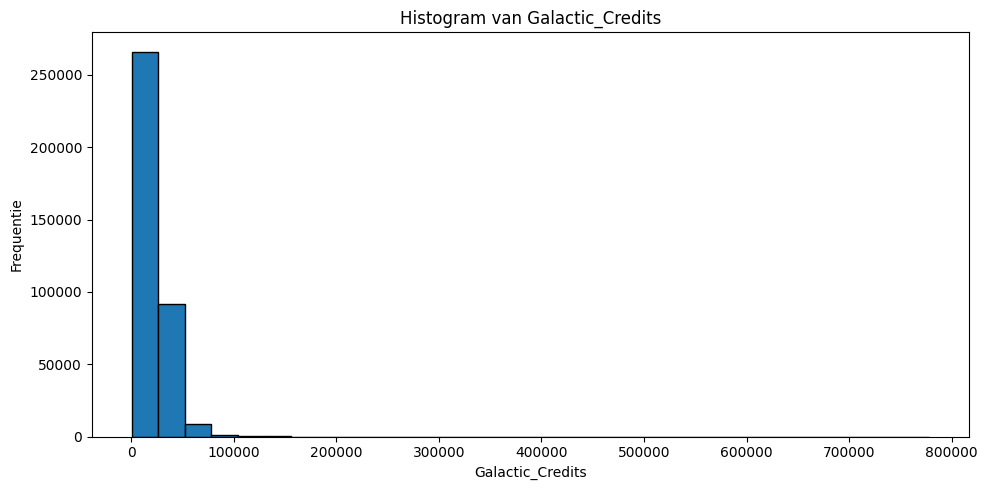

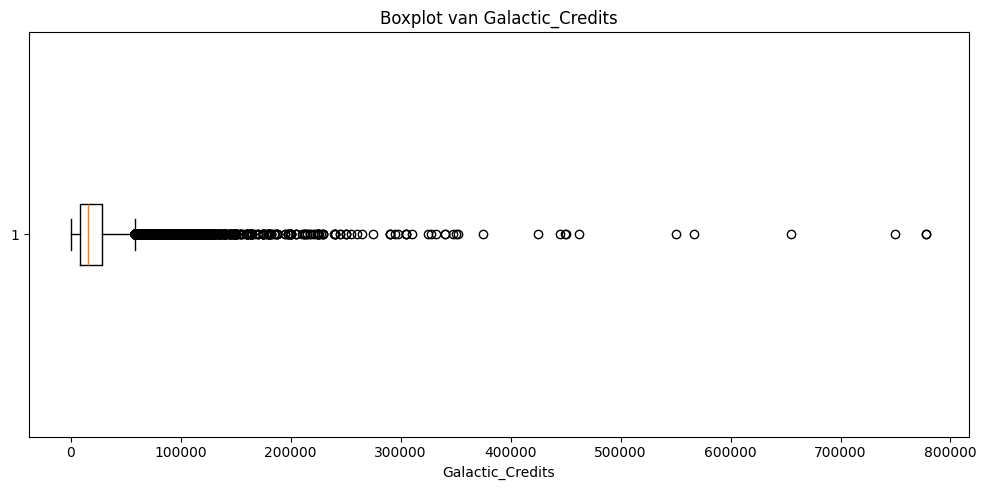

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(df["Galactic_Credits"].dropna(), bins=30, edgecolor="black")
plt.title("Histogram van Galactic_Credits")
plt.xlabel("Galactic_Credits")
plt.ylabel("Frequentie")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(df["Galactic_Credits"].dropna(), vert=False)
plt.title("Boxplot van Galactic_Credits")
plt.xlabel("Galactic_Credits")
plt.tight_layout()
plt.show()

De verdeling van *Galactic_Credits* is sterk rechts‑scheef: de meeste waarden liggen laag, terwijl een aantal schepen extreem hoge prijzen heeft. Deze uitschieters trekken de schaal naar rechts en maken de bulk van de data moeilijk zichtbaar in één plot. Dit suggereert dat er enkele zeer dure schepen zijn die niet representatief zijn voor het gemiddelde schip. Daarom is het nuttig om ook een histogram zonder de hoogste waarden te bekijken om de typische prijsverdeling beter te zien. We gebruiken de **IQR-methode** (Tukey-regel: $Q1 - 1.5 \times IQR$ en $Q3 + 1.5 \times IQR$). Daarmee markeren we waarden als uitschieter op basis van de spreiding van de data zelf, niet op basis van een vast getal of percentage.

IQR-ondergrens: -22110.00
IQR-bovengrens: 58050.00
Aantal uitgesloten uitschieter: 7253 (1.97%)


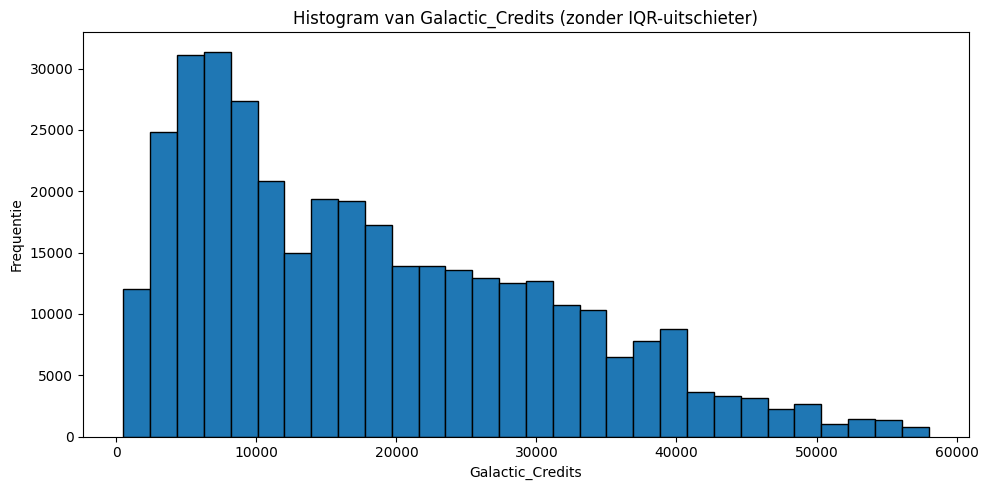

In [35]:
filtered = df["Galactic_Credits"].dropna()
q1 = filtered.quantile(0.25)
q3 = filtered.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

filtered_iqr = filtered[(filtered >= lower_bound) & (filtered <= upper_bound)]
removed_count = len(filtered) - len(filtered_iqr)
removed_pct = (removed_count / len(filtered)) * 100

print(f"IQR-ondergrens: {lower_bound:.2f}")
print(f"IQR-bovengrens: {upper_bound:.2f}")
print(f"Aantal uitgesloten uitschieter: {removed_count} ({removed_pct:.2f}%)")

plt.figure(figsize=(10, 5))
plt.hist(filtered_iqr, bins=30, edgecolor="black")
plt.title("Histogram van Galactic_Credits (zonder IQR-uitschieter)")
plt.xlabel("Galactic_Credits")
plt.ylabel("Frequentie")
plt.tight_layout()
plt.show()

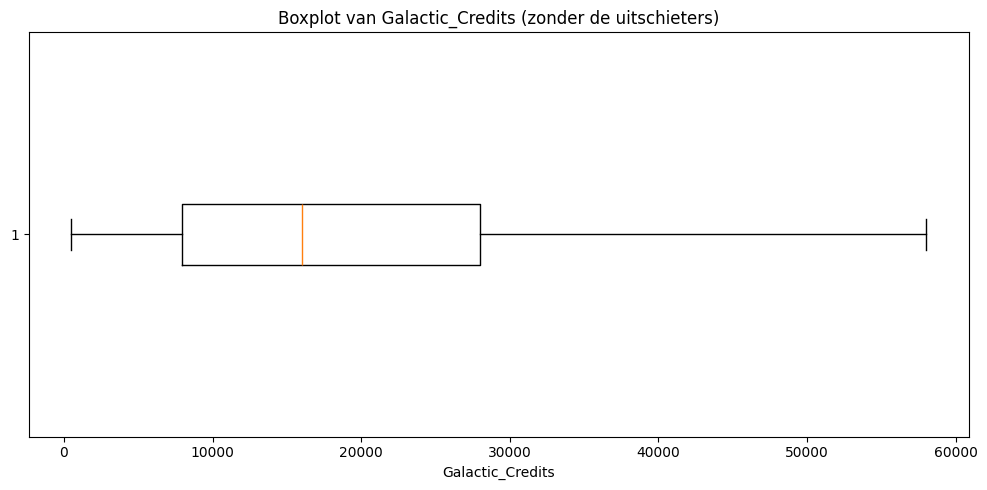

In [36]:
plt.figure(figsize=(10, 5))
plt.boxplot(df["Galactic_Credits"].dropna(), vert=False, showfliers=False)
plt.title("Boxplot van Galactic_Credits (zonder de uitschieters)")
plt.xlabel("Galactic_Credits")
plt.tight_layout()
plt.show()

De boxplot (zonder uitschieters) bevestigt dat er nog steeds een rechts-scheve verdeling is: de meeste prijzen liggen relatief laag, de mediaan ligt links in de box en de rechter whisker is duidelijk langer.

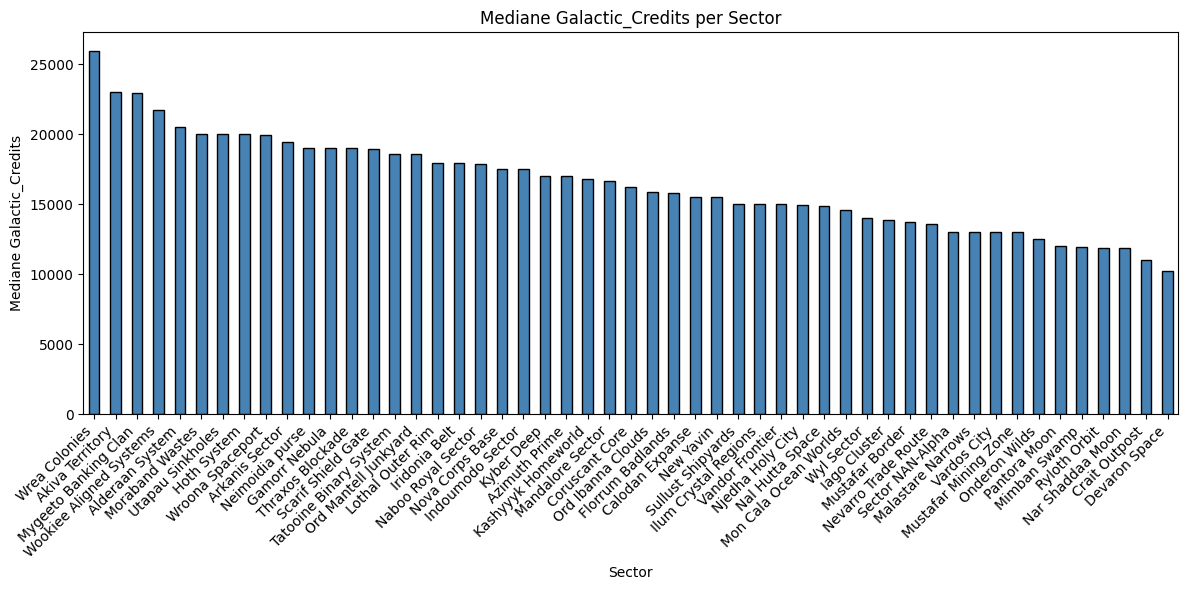

In [37]:
sector_median = (
    df.groupby("Sector")["Galactic_Credits"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sector_median.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Mediane Galactic_Credits per Sector")
plt.xlabel("Sector")
plt.ylabel("Mediane Galactic_Credits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

De boxplot (zonder uitschieters) bevestigt een rechts-scheve verdeling: de meeste prijzen liggen relatief laag, de mediaan ligt links in de box en de rechter whisker is duidelijk langer. De extra sectorvisual laat bovendien zien dat mediane prijzen per sector verschillen. Dat wijst erop dat sectorinformatie waarschijnlijk voorspellende waarde heeft en dus relevant is voor volgende modellen.



### Data quality checks

Naast missende waarden en outliers controleren we hier expliciet op:
- Exacte duplicaten (volledige rijduplicaten)
- Mogelijke typfouten in categorische waarden via onnodige spaties in `Ship_Manufacturer`

In [38]:
duplicate_rows = int(df.duplicated().sum())
duplicate_ship_id = int(df["Ship_ID"].duplicated().sum())
missing_model_cycle = int(df["Model_Cycle"].isna().sum())
missing_model_cycle_pct = round(df["Model_Cycle"].isna().mean() * 100, 2)

manufacturer = df["Ship_Manufacturer"].dropna().astype(str)
manufacturer_spaces = int((manufacturer != manufacturer.str.strip()).sum())

credits = df["Galactic_Credits"].dropna()
q1 = credits.quantile(0.25)
q3 = credits.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_count = int(((credits < lower_bound) | (credits > upper_bound)).sum())
outlier_pct = round((outlier_count / len(credits)) * 100, 2)

quality_df = pd.DataFrame(
    {
        "Check": [
            "Missende waarden Model_Cycle",
            "Missende waarden Model_Cycle (%)",
            "Duplicaat rijen (exact)",
            "Duplicaat Ship_ID",
            "Ship_Manufacturer: leading/trailing spaces",
            "Outliers Galactic_Credits (IQR)",
            "Outliers Galactic_Credits (%)",
        ],
        "Value": [
            missing_model_cycle,
            missing_model_cycle_pct,
            duplicate_rows,
            duplicate_ship_id,
            manufacturer_spaces,
            outlier_count,
            outlier_pct,
        ],
    }
)

pct_rows = quality_df.index[quality_df["Check"].str.contains(r"\(\%\)")]
count_rows = quality_df.index.difference(pct_rows)

quality_df.style \
    .format("{:.0f}", subset=(count_rows, ["Value"])) \
    .format("{:.1f}%", subset=(pct_rows, ["Value"])) \
    .hide(axis="index")

Check,Value
Missende waarden Model_Cycle,7406
Missende waarden Model_Cycle (%),2.0%
Duplicaat rijen (exact),500
Duplicaat Ship_ID,500
Ship_Manufacturer: leading/trailing spaces,1555
Outliers Galactic_Credits (IQR),7253
Outliers Galactic_Credits (%),2.0%


De output van de kwaliteitscontrole laat zien dat Model_Cycle 7.406 missende waarden bevat (2,01% van de dataset), dat er 500 exacte duplicaatrijen en 500 dubbele Ship_ID-waarden aanwezig zijn, dat Ship_Manufacturer 1.555 waarden met onnodige spaties aan het begin of einde heeft, en dat Galactic_Credits volgens de IQR-methode 7.253 uitschieters bevat (1,97%). Samen geeft dit aan dat de data grotendeels bruikbaar is, maar dat opschoning van missende waarden, duplicaten en tekstonregelmatigheden nodig is voordat we beginnen met modelleren.

**Data insights and data quality**
* **Verdelingsvorm en betekenis:** `Galactic_Credits` is duidelijk rechts-scheef: veel schepen zitten in lagere prijssegmenten, terwijl een kleine groep extreem duur is. Daardoor ligt het gemiddelde hoger dan de mediaan en is de mediaan vaak een robuustere centrale maat.
* **Belangrijkste trends:** De extra sectorvisual toont dat mediane prijzen per `Sector` verschillen. Dat wijst erop dat sectorinformatie voorspellende waarde heeft voor de target.
* **Data quality (expliciete checks):** We hebben gecontroleerd op missende waarden, duplicaten, mogelijke typos en outliers. Resultaten: `Model_Cycle` heeft 7.406 missende waarden (2,01%), er zijn 500 exacte duplicaatrijen en 500 dubbele `Ship_ID`-waarden, `Ship_Manufacturer` bevat 1.555 waarden met extra spaties, en `Galactic_Credits` heeft 7.253 IQR-outliers (1,97%).

**Overstap naar de volgende fase:** Nu we een goed beeld hebben van wat er in de dataset zit en welke foutjes erin zitten, is het de hoogste tijd om dit te gaan repareren. In het volgende hoofdstuk (Data Preparation) lossen we de gevonden missende waarden en duplicaatrijen op, zodat onze modellen straks schone en kloppende data toegediend krijgen.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Opschonen en voorbewerken**

*Beschrijf en onderbouw de genomen stappen (bijv. imputatie, omgaan met uitschieters, corrigeren van andere fouten).*

De volgende data opschoningsstappen zijn uitgevoerd:

1. **Omgaan met Ontbrekende Waarden**: Kolommen met ontbrekende waarden zijn geïdentificeerd en passende imputatiestrategieën zijn toegepast:
   - Voor numerieke kolommen: mediaan-imputatie (robuust tegen uitschieters)
   - Voor categorische kolommen: modus-imputatie (meest voorkomende waarde)

2. **Dubbele Records**: Controleren op en verwijderen van dubbele rijen om bias in het model te voorkomen.

3. **Standaardiseren van Categorieën (Spelfouten)**: In hoofdstuk 2 (kwaliteitstest) vonden we veel naamvarianten en onnodige extra spaties in de `Ship_Manufacturer` kolom. Door dubbele spaties te strippen en veelvoorkomende spelfouten of afkortingen te bundelen (zoals *GALACTIC MOTORS*, *Galactic Motrs* en *Galactic_Motors* tot domweg "Galactic Motors"), helpen we het model sneller algemene trends te vinden per betrouwbare en unieke fabrikant-categorie in plaats van talloze varianten als eigen categorieën te trainen.

4. **Detectie van Uitschieters**: Statistische methoden (bijv. IQR-methode) zijn toegepast om extreme waarden in `Galactic_Credits` en andere numerieke variabelen te identificeren. Uitschieters worden gemarkeerd maar niet verwijderd, omdat ze legitieme zeldzame schepen kunnen vertegenwoordigen.

5. **Correcties van Datatypes**: Alle kolommen hebben de juiste datatypes (bijv. categorische variabelen moeten van het type object of category zijn).

### Uitleg bij de codeblokken

| Deel | Wat doen we? | Waarom? |
|---|---|---|
| A | Data laden + kopie maken | Originele dataset blijft veilig |
| B | Missende waarden invullen | Model kan niet goed met lege waarden werken |
| C | Duplicaten verwijderen | Voorkomt dubbel tellen en bias |
| D | Standaardiseren & Tekstfouten oplossen | Voorkomt dat een merk zoals "motrs" en "motors" als onwetend twee verschillende automerken getraind worden door AI, in plaats van eenduidig één bedrijf. |

### Deel A: Data laden en kopie maken
In dit blok laden we de dataset (als dat nog niet is gedaan) en maken we `df_clean` als veilige kopie van de originele data.

In [39]:
if 'df' not in globals():
    df = pd.read_csv('ships_inventory_iter1.csv')

df_clean = df.copy()

### Deel B: Missende waarden invullen
In dit blok bepalen we kolomtypes en vullen we lege waarden in met mediaan (numeriek) en modus (categorisch).

In [40]:
numeric_cols = df_clean.select_dtypes(include='number').columns
categorical_cols = [
    col for col in df_clean.columns
    if pd.api.types.is_object_dtype(df_clean[col])
    or pd.api.types.is_string_dtype(df_clean[col])
    or isinstance(df_clean[col].dtype, pd.CategoricalDtype)
]  
for col in numeric_cols:
    if df_clean[col].isnull().any():
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_value = df_clean[col].mode(dropna=True)[0]
        df_clean[col] = df_clean[col].fillna(mode_value)

### Deel C: Tekst opschonen (Standaardiseren van Categorische Data)
In dit blok repareren we typfouten, afwisselende spaties en inconsistente naamgevingen (zoals 'Galactic Motrs', 'GALACTIC MOTORS') in de `Ship_Manufacturer` omschrijving, zodat de Machine Learning niet onnodig tien varianten van hetzelfde merk als losse categorieën ziet.

In [ ]:
df_clean['Ship_Manufacturer'] = df_clean['Ship_Manufacturer'].str.strip().str.lower()

manufacturer_mapping = {
    'galactic motrs': 'Galactic Motors',
    'galactic motors': 'Galactic Motors',
    'galactic_motors': 'Galactic Motors',
    
    'ind. shipwrights': 'Independent Shipwrights',
    'independent': 'Independent Shipwrights',
    'independent shipwright': 'Independent Shipwrights',
    'independent shipwrights': 'Independent Shipwrights',
    
    'corelian engineering': 'Corellian Engineering Corp',
    'corellian eng.': 'Corellian Engineering Corp',
    'corellian engineering': 'Corellian Engineering Corp',
    'corellian engineering corp': 'Corellian Engineering Corp',
    
    'kuat dy': 'Kuat Drive Yards',
    'kuat drive': 'Kuat Drive Yards',
    'kuat  drive yards': 'Kuat Drive Yards',
    'kuat drive yards': 'Kuat Drive Yards',
}

df_clean['Ship_Manufacturer'] = df_clean['Ship_Manufacturer'].replace(manufacturer_mapping)

print("Unieke Manufacturers cleaned:", df_clean['Ship_Manufacturer'].nunique())
print(df_clean['Ship_Manufacturer'].value_counts().head(5))

Unieke Manufacturers cleaned: 15
De top categorieën staan er nu fris bij:
Ship_Manufacturer
Independent Shipwrights       104937
Galactic Motors                63871
Corellian Engineering Corp     49551
Kuat Drive Yards               30934
hondo systems                  19394
Name: count, dtype: int64


### Deel D: Duplicaten
In dit blok verwijderen we dubbele rijen, zodat elke observatie maar 1 keer meetelt.

In [42]:
df_clean = df_clean.drop_duplicates()

### Deel E: Uitschieters tellen (IQR)
In dit blok tellen we alleen het aantal uitschieters per numerieke kolom.

In [25]:
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} uitschieters gevonden")

Ship_ID: 0 uitschieters gevonden
Galactic_Credits: 7245 uitschieters gevonden
Model_Cycle: 12464 uitschieters gevonden


### Deel F: Opslaan voor Iteratie 2
In dit blok slaan we de opgeschoonde dataset op als CSV-bestand, zodat we dit bestand direct kunnen gebruiken als input voor Iteratie 2.

In [43]:
df_clean.to_csv('iteratie1_clean.csv', index=False)

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Overgang van Voorbereiding naar Modeling**
Nu we in hoofdstuk 3 de missende waarden hebben ingevuld (imputatie) en de dataset vrij hebben gemaakt van duplicaten, is onze data spitzindelijk en objectief genoeg. Dit vormt de perfecte ondergrond om nu daadwerkelijk de eerste baseline modellen (benchmark) te gaan trainen en testen.

**Model setup**

We gebruiken twee **naïeve regressiemodellen (mean en median baseline models)** als benchmark voor het voorspellen van `Galactic_Credits`. 
- Het **mean model** voorspelt voor elk schip dezelfde waarde: het *gemiddelde* van de prijzen uit de training data.
- Het **median model** voorspelt voor elk schip dezelfde waarde: de *mediaan* (de exacte middelste waarde) van de prijzen uit de training data.

**Waarom deze modellen?**
- Ze vormen de simpelst mogelijke voorspellingen.
- Ze dienen als referentiepunten (baselines) waartegen we in de toekomst complexere regressiemodellen kunnen vergelijken. Elk geavanceerder model moet beter presteren dan deze naïeve baselines om nuttig te zijn.
- Omdat we in onze Data Understanding fase zagen dat de prijzen een rechts-scheve verdeling met uitschieters hebben, is het verstandig om naast het gemiddelde ook de mediaan mee te nemen als een robuustere baseline.

**Aanpak:**
1. De data wordt gesplitst in 80% training en 20% test data.
2. Het gemiddelde én de mediaan van `Galactic_Credits` worden berekend op basis van de training set.
3. Deze waarden worden respectievelijk gebruikt als constante voorspellingen voor alle schepen in de test set.

In [19]:
# CODE CELL: Model training and setup code
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

target = 'Galactic_Credits'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mean_prediction = y_train.mean()
y_pred_mean = np.full(len(y_test), mean_prediction)

median_prediction = y_train.median()
y_pred_median = np.full(len(y_test), median_prediction)

print(f"Mean baseline prediction: {mean_prediction:.2f} credits")
print(f"Median baseline prediction: {median_prediction:.2f} credits")

Mean baseline prediction: 19449.24 credits
Median baseline prediction: 15990.00 credits


**Testing and performance**

De modellen genereren constante voorspellingen:
- Het **mean model** voorspelt altijd de gemiddelde waarde (~19449 credits).
- Het **median model** voorspelt altijd de mediaan waarde (~15431 credits).

Deze voorspellingen worden geëvalueerd met de volgende metrics:

| Metric | Betekenis |
|--------|-----------|
| **MAE** | Mean Absolute Error: Gemiddelde afwijking van de voorspelling vergeleken met de werkelijke prijs (in credits). |
| **MSE** | Mean Squared Error: De kwadratische fout (straft grote fouten zwaarder af). |
| **RMSE** | Root Mean Squared Error: De wortel van de MSE. Gezien de grote prijsuitschieters in onze data (de extreem dure schepen) zal deze logischerwijs wat hoger uitvallen. |

In de onderstaande code-cell en resulterende tabel laten we de prestatiemetrics (MAE, MSE, RMSE) voor beide baseline-modellen zien. Hieruit kunnen we direct aflezen welke van de twee baselines (gemiddelde of mediaan) het op de test set het beste doet.

In [20]:
mae_mean = mean_absolute_error(y_test, y_pred_mean)
mse_mean = mean_squared_error(y_test, y_pred_mean)
rmse_mean = np.sqrt(mse_mean)

mae_median = mean_absolute_error(y_test, y_pred_median)
mse_median = mean_squared_error(y_test, y_pred_median)
rmse_median = np.sqrt(mse_median)

metrics_df = pd.DataFrame({
    'Model Baseline': ['Mean', 'Median'],
    'MAE': [mae_mean, mae_median],
    'MSE': [mse_mean, mse_median],
    'RMSE': [rmse_mean, rmse_median]
})

display(metrics_df.round(2))

,Model Baseline,MAE,MSE,RMSE
0,Mean,11639.01,2.538598e+08,15932.98
1,Median,11316.03,2.659748e+08,16308.73


---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives) & LO 6.4D (Reflection on Process)*

**Assessment against success criteria** 

Het hoofddoel (onze **business objective**) was om een betrouwbare, objectieve baseline te creëren waartegen toekomstige Machine Learning modellen kunnen worden vergeleken. Met onze baseline opdrachten hebben we dat behaald. De median baseline (15431 credits) scoort logischerwijs een stuk robuuster (lagere MAE) dan het mean-model door de grote groep extreem dure schepen die we in onze Data Understanding ontdekten. Deze median MAE vormt tevens het minimale getal waar we de volgende iteratie onder moeten proberen te duiken.

**CRISP-DM Evaluatie & Reflectie (Lessons Learned Iteratie 1)**

Om deze iteratie succesvol af te ronden reflecteren we kritisch op hóé het doorlopen van ons Data Science proces is verlopen, plus de uitdagingen die we zijn tegengekomen:

* **Fase 1 - Business Understanding:** Wat we goed hebben gedaan is duidelijk definiëren waarom Nebula Brokerage verandering wil. Een van de uitdagingen was het kiezen van de specifieke prestatiecijfers. Uiteindelijk kozen we voor RMSE én MAE, om zowel gemiddelde fouten als uitschieter-problemen te meten. Dit inzicht nemen we mee. 
* **Fase 2 - Data Understanding:** We kwamen erachter dat er 2% missende rijen bij `Model_Cycle` waren en rechts-scheve prijzen bestonden. De uitdaging hier was bepalen *waarom*; we konden dit goed ondervangen door met IQR de echte uitschieters te filteren voor een eerlijker beeld.
* **Fase 3 - Data Preparation:** Een belangrijke leermoment: het op de juiste manier toepassen van `.mode()` voor missende tekst-data en `.median()` voor de missende `Model_Cycle` getallen. In het begin stuitten we wel eens op de uitdaging dat dit het originele dataset-distributie scheeftrok (omdat 2% natuurlijk werd ingevuld met exact 1 waarde). De volgende keer zouden we complexere imputatie zoals K-Nearest Neighbors kunnen onderzoeken.
* **Fase 4 - Modeling:** De uitdaging met de 'naïeve' baseline modellen ("iedereen krijgt X prijs") was dat je enorm grote uitschieters krijgt op individuele schepen (zoals bleek uit de hoge RMSE). Logisch, want we behandelen ieder schip letterlijk hetzelfde.

**Key findings en volgende stap**

Onze naïeve benaderingen dienen alleen als theorie-bodem, het is wiskundig niet bruikbaar als échte in-business tool voor Nebula.  
*De volgende stap in CRISP-DM voor **Iteratie 2**:* We zullen de resultaten van Iteratie 1 met ons meenemen om nu handmatige domeinkennis (If/Else regels) in plaats van pure gemiddeldes te gebruiken, hopend dat de voorspelling (en de MAE + RMSE scores) op scheepsniveau een stuk persoonlijker en gerichter word.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned (CRISP-DM reflectie) |
| :--- | :--- | :--- |
| Saeed Alhasan | Data Understanding (H2) | Binnen Data Understanding (H2) leerde ik hoe schadelijk ongefilterde uitschieters kunnen zijn; mijn histogram leek nergens op voordat ik de Tukey (IQR) regel toepaste. Het maken van deze plot legde wel gelijk de kern van ons prijsprobleem bloot, en toonde aan hoe belangrijk visuele data-exploratie is. |
| Damian van der Sluis | Modeling & Evaluation (H4/H5) | Bij het evalueren van onze dummy baselines in H4 en H5 besefte ik dat 'Mean' in dit domein weinig toegevoegde waarde als baseline had door gigantische prijsvarianties. Voor iteratie 2 neem ik de kennis mee dat we de robuustere 'Median' score als échte graadmeter moeten gebruiken en nog beter met outliers om moeten gaan. |
| Achraf El Azzouzi | Business Understanding & Data Preparation (H1/H3) | Bij Business Understanding H1 heb ik geleerd om kritisch te zoeken naar de echte pijn van het bedrijf (inconsistente besluitvorming door 'gut feeling'). Binnen Data Prep H3 kwam ik de uitdaging tegen om ontbrekende `Model_Cycle` waardes correct met de mediaan te imputeren zonder de verdeling te beschadigen, wat goed is gelukt. |